In [1]:
!git clone https://github.com/Adhishree22/Fraud_Detection.git
%cd Fraud_Detection

Cloning into 'Fraud_Detection'...
remote: Enumerating objects: 365, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 365 (delta 68), reused 24 (delta 19), pack-reused 218 (from 1)
Receiving objects: 100% (365/365), 12.73 MiB | 12.21 MiB/s, done.
Resolving deltas: 100% (160/160), done.
/content/Fraud_Detection


In [2]:
!gdown https://drive.google.com/uc?id=12IR_M_ier895LtfgkmvyhUUuiR_AKpi9

Downloading...
From (original): https://drive.google.com/uc?id=12IR_M_ier895LtfgkmvyhUUuiR_AKpi9
From (redirected): https://drive.google.com/uc?id=12IR_M_ier895LtfgkmvyhUUuiR_AKpi9&confirm=t&uuid=e5cf41ce-6505-41c4-b7c1-056a1141447f
To: /content/Fraud_Detection/ieee-fraud-detection.zip
100% 124M/124M [00:01<00:00, 63.9MB/s]


In [3]:
!unzip ieee-fraud-detection.zip -d fraud_data

Archive:  ieee-fraud-detection.zip
  inflating: fraud_data/sample_submission.csv  
  inflating: fraud_data/test_identity.csv  
  inflating: fraud_data/test_transaction.csv  
  inflating: fraud_data/train_identity.csv  
  inflating: fraud_data/train_transaction.csv  


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [5]:
from python.ingestion import *

path = "fraud_data/"

transaction_file = path + "train_transaction.csv"
identity_file = path + "train_identity.csv"

transactions_cols = [ "TransactionID", "TransactionDT", "TransactionAmt", "ProductCD", "card1", "card2",
                     "card3", "card4", "card5", "card6", "addr1", "addr2", "dist1", "dist2", "P_emaildomain",
                      "R_emaildomain","M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9", "isFraud" ]

identity_col = ["TransactionID", "DeviceType", "DeviceInfo",  "id_30",  "id_31",  "id_33"]

transactions_df = load_dataset(path + "train_transaction.csv", transactions_cols)
identity_df = load_dataset(path + "train_identity.csv", identity_col)

In [6]:
from python.validation import *

dataset_overview(transactions_df, "Transactions");

Transactions Overview


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,T,T,T,M2,F,T,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,T,T,T,M0,F,F,F,F,F
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Metric,Value
0,Rows,590540
1,Columns,26
2,Missing Cells,4255561
3,Missing Percent,27.72%
4,Duplicate Rows,0
5,Duplicate Percent,0.0%


In [7]:
schema_validation(transactions_df, "Transactions");

,Column,DataType,Missing_Count,Missing_Percentage
0,dist2,float64,552913,93.63
1,R_emaildomain,object,453249,76.75
2,dist1,float64,352271,59.65
3,M5,object,350482,59.35
4,M7,object,346265,58.64
5,M8,object,346252,58.63
6,M9,object,346252,58.63
7,M4,object,281444,47.66
8,M3,object,271100,45.91
9,M1,object,271100,45.91


In [8]:
cardinality_overview(transactions_df);

Cardinality Overview


,Column,Unique_Values
0,TransactionID,590540
2,TransactionDT,573349
3,TransactionAmt,20902
5,card1,13553
13,dist1,2651
14,dist2,1751
6,card2,500
11,addr1,332
9,card5,119
7,card3,114


In [9]:
fraud_distribution(transactions_df);


Overall Fraud Rate: 3.5%


,Fraud_Label,Count,Percentage
0,0,569877,96.5
1,1,20663,3.5


In [10]:
numeric_overview(transactions_df);


Numeric Feature Overview


,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3282269.50,170474.36,2987000.00,3134634.75,3282269.50,3429904.25,3577539.00
isFraud,590540.0,0.03,0.18,0.00,0.00,0.00,0.00,1.00
TransactionDT,590540.0,7372311.31,4617223.65,86400.00,3027057.75,7306527.50,11246620.00,15811131.00
TransactionAmt,590540.0,135.03,239.16,0.25,43.32,68.77,125.00,31937.39
card1,590540.0,9898.73,4901.17,1000.00,6019.00,9678.00,14184.00,18396.00
card2,581607.0,362.56,157.79,100.00,214.00,361.00,512.00,600.00
card3,588975.0,153.19,11.34,100.00,150.00,150.00,150.00,231.00
card5,586281.0,199.28,41.24,100.00,166.00,226.00,226.00,237.00
addr1,524834.0,290.73,101.74,100.00,204.00,299.00,330.00,540.00
addr2,524834.0,86.80,2.69,10.00,87.00,87.00,87.00,102.00


In [11]:
dataset_overview(identity_df, "Identity");

Identity Overview


,TransactionID,id_30,id_31,id_33,DeviceType,DeviceInfo
0,2987004,Android 7.0,samsung browser 6.2,2220x1080,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,iOS 11.1.2,mobile safari 11.0,1334x750,mobile,iOS Device
2,2987010,NaN,chrome 62.0,NaN,desktop,Windows
3,2987011,NaN,chrome 62.0,NaN,desktop,NaN
4,2987016,Mac OS X 10_11_6,chrome 62.0,1280x800,desktop,MacOS


,Metric,Value
0,Rows,144233
1,Columns,6
2,Missing Cells,170553
3,Missing Percent,19.71%
4,Duplicate Rows,0
5,Duplicate Percent,0.0%


In [12]:
schema_validation(identity_df, "Identity");

,Column,DataType,Missing_Count,Missing_Percentage
0,id_33,object,70944,49.19
1,id_30,object,66668,46.22
2,DeviceInfo,object,25567,17.73
3,id_31,object,3951,2.74
4,DeviceType,object,3423,2.37
5,TransactionID,int64,0,0.00


In [13]:
cardinality_overview(identity_df);

Cardinality Overview


,Column,Unique_Values
0,TransactionID,144233
5,DeviceInfo,1786
3,id_33,260
2,id_31,130
1,id_30,75
4,DeviceType,2


In [14]:
transactions_sample, identity_sample = create_time_split(transactions_df, identity_df, sample_size=100000)


Time-Ordered Sample:
Transactions: (100000, 26)
Time range: 86400 to 2006364
Filtered Identity: (41446, 6)


In [15]:
transactions_sample_clean = remove_duplicates(transactions_sample, "TransactionID")

identity_sample_clean  = remove_duplicates(identity_sample, "TransactionID")

In [16]:
transactions_sample_clean.to_csv("transactions_clean.csv",index=False)
identity_sample_clean.to_csv("identity_clean.csv",index=False)

In [17]:
from google.colab import files

files.download("transactions_clean.csv")
files.download("identity_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
dataset_overview(transactions_sample_clean, "Transaction Sample");

Transaction Sample Overview


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,T,T,T,M2,F,T,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,T,T,T,M0,F,F,F,F,F
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Metric,Value
0,Rows,100000
1,Columns,26
2,Missing Cells,891959
3,Missing Percent,34.31%
4,Duplicate Rows,0
5,Duplicate Percent,0.0%


In [19]:
schema_validation(transactions_sample_clean, "Transaction Sample");

,Column,DataType,Missing_Count,Missing_Percentage
0,dist2,float64,91769,91.77
1,M7,object,83961,83.96
2,M8,object,83961,83.96
3,M9,object,83961,83.96
4,dist1,float64,69653,69.65
5,M5,object,68924,68.92
6,M2,object,68553,68.55
7,M1,object,68553,68.55
8,M3,object,68553,68.55
9,R_emaildomain,object,65454,65.45


In [20]:
cardinality_overview(transactions_sample_clean);

Cardinality Overview


,Column,Unique_Values
0,TransactionID,100000
2,TransactionDT,96144
5,card1,7677
3,TransactionAmt,6387
13,dist1,1641
14,dist2,916
6,card2,499
11,addr1,264
9,card5,87
7,card3,74


In [21]:
fraud_distribution(transactions_sample_clean);


Overall Fraud Rate: 2.56%


,Fraud_Label,Count,Percentage
0,0,97439,97.44
1,1,2561,2.56


In [22]:
numeric_overview(transactions_sample_clean);


Numeric Feature Overview


,count,mean,std,min,25%,50%,75%,max
TransactionID,100000.0,3036999.50,28867.66,2987000.00,3011999.75,3036999.5,3061999.25,3086999.00
isFraud,100000.0,0.03,0.16,0.00,0.00,0.0,0.00,1.00
TransactionDT,100000.0,1135123.78,573348.38,86400.00,653748.75,1189342.5,1643471.00,2006364.00
TransactionAmt,100000.0,130.74,206.02,0.29,45.00,75.0,135.95,4829.95
card1,100000.0,9878.40,4933.56,1001.00,6019.00,9653.0,14290.00,18395.00
card2,98646.0,370.89,159.24,100.00,215.00,387.0,514.00,600.00
card3,99997.0,153.24,11.15,100.00,150.00,150.0,150.00,229.00
card5,99475.0,200.07,40.91,100.00,166.00,226.0,226.00,237.00
addr1,90963.0,291.41,103.08,100.00,204.00,299.0,330.00,540.00
addr2,90963.0,86.24,5.06,13.00,87.00,87.0,87.00,102.00


In [23]:
dataset_overview(identity_sample_clean, "Identity Sample");

Identity Sample Overview


,TransactionID,id_30,id_31,id_33,DeviceType,DeviceInfo
0,2987004,Android 7.0,samsung browser 6.2,2220x1080,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,iOS 11.1.2,mobile safari 11.0,1334x750,mobile,iOS Device
2,2987010,NaN,chrome 62.0,NaN,desktop,Windows
3,2987011,NaN,chrome 62.0,NaN,desktop,NaN
4,2987016,Mac OS X 10_11_6,chrome 62.0,1280x800,desktop,MacOS


,Metric,Value
0,Rows,41446
1,Columns,6
2,Missing Cells,32839
3,Missing Percent,13.21%
4,Duplicate Rows,0
5,Duplicate Percent,0.0%


In [24]:
schema_validation(identity_sample_clean, "Identity Sample");

,Column,DataType,Missing_Count,Missing_Percentage
0,id_33,object,13881,33.49
1,id_30,object,11610,28.01
2,DeviceInfo,object,4981,12.02
3,id_31,object,1204,2.90
4,DeviceType,object,1163,2.81
5,TransactionID,int64,0,0.00


In [25]:
cardinality_overview(identity_sample_clean);

Cardinality Overview


,Column,Unique_Values
0,TransactionID,41446
5,DeviceInfo,866
3,id_33,132
2,id_31,82
1,id_30,67
4,DeviceType,2


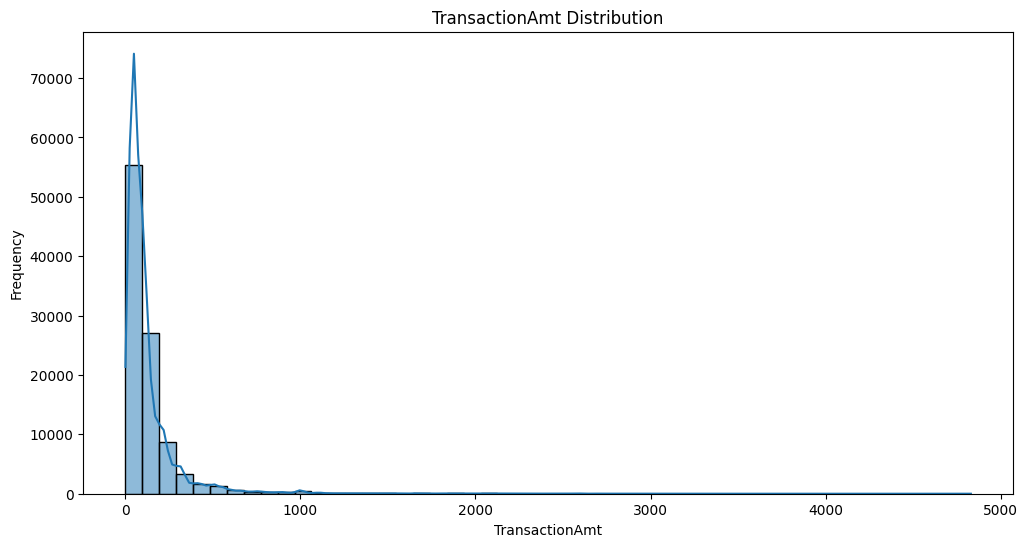

In [26]:
from python.eda import *

#Transaction Amount
distribution_plot(transactions_sample_clean,"TransactionAmt");

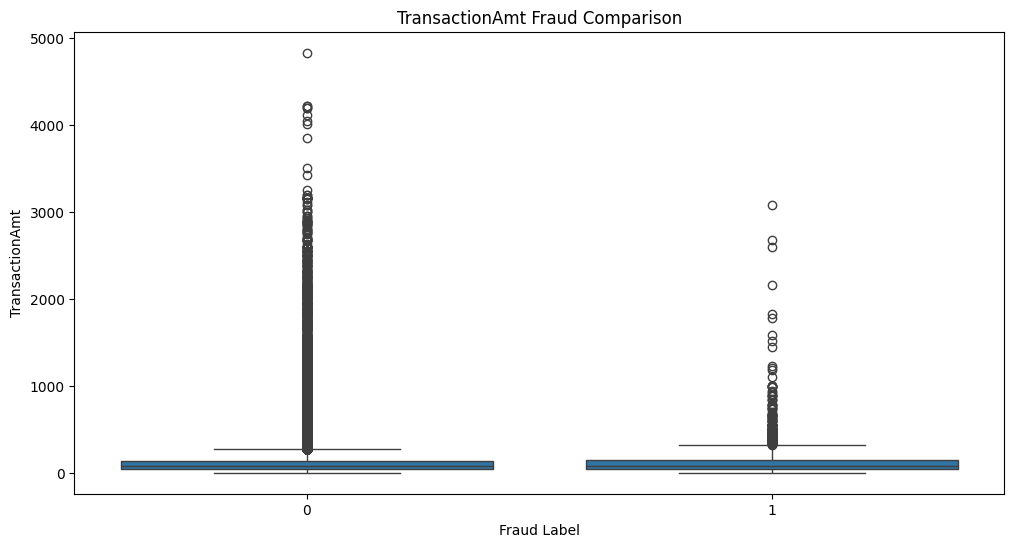

In [27]:
fraud_distribution_plot(transactions_sample_clean,"TransactionAmt") ;

In [28]:
outlier_analysis(transactions_sample_clean,"TransactionAmt") ;

TransactionAmt Outlier Analysis
Lower Bound: -91.42
Upper Bound: 272.38
Outlier Count: 9568
Outlier Percentage: 9.57 %


In [29]:
percentile_analysis(transactions_sample_clean,"TransactionAmt") ;

TransactionAmt Percentile Analysis


,Percentile,Value
0,50th Percentile,75.00
1,75th Percentile,135.95
2,90th Percentile,255.00
3,95th Percentile,408.90
4,99th Percentile,1000.00


In [30]:
skewness_analysis(transactions_sample_clean,["TransactionAmt"]);

Skewness Analysis


,Feature,Skewness
0,TransactionAmt,6.78


In [31]:
#Distance Feature

distance_cols = ["dist1","dist2" ]
fraud_behavior_summary(transactions_sample_clean,distance_cols,"Distance Feature Fraud Analysis" ) ;

Distance Feature Fraud Analysis Fraud Comparison


,Feature,Non_Fraud_Mean,Fraud_Mean,Difference
0,dist1,123.83,146.92,23.09
1,dist2,238.85,213.43,-25.42


In [32]:
skewness_analysis(transactions_sample_clean,distance_cols );

Skewness Analysis


,Feature,Skewness
1,dist2,5.02
0,dist1,4.89


In [33]:
missing_signal_results = missing_signal_fraud_analysis(transactions_sample_clean)
missing_signal_results

,Feature,Missing_Count,Present_Count,Missing_Pct,Present_Pct,Missing_Fraud_Transactions,Fraud_Contribution_Pct,Fraud_Rate_Missing_Pct,Fraud_Rate_Present_Pct,Fraud_Lift
0,card3,3,99997,0.00,100.00,2,0.08,66.67,2.56,26.05
1,card6,4,99996,0.00,100.00,2,0.08,50.00,2.56,19.54
2,card4,7,99993,0.01,99.99,2,0.08,28.57,2.56,11.16
3,addr1,9037,90963,9.04,90.96,764,29.83,8.45,1.98,4.28
4,addr2,9037,90963,9.04,90.96,764,29.83,8.45,1.98,4.28
5,M8,83961,16039,83.96,16.04,2355,91.96,2.80,1.28,2.18
6,M9,83961,16039,83.96,16.04,2355,91.96,2.80,1.28,2.18
7,M7,83961,16039,83.96,16.04,2355,91.96,2.80,1.28,2.18
8,card5,525,99475,0.52,99.48,28,1.09,5.33,2.55,2.09
9,M6,45587,54413,45.59,54.41,1532,59.82,3.36,1.89,1.78


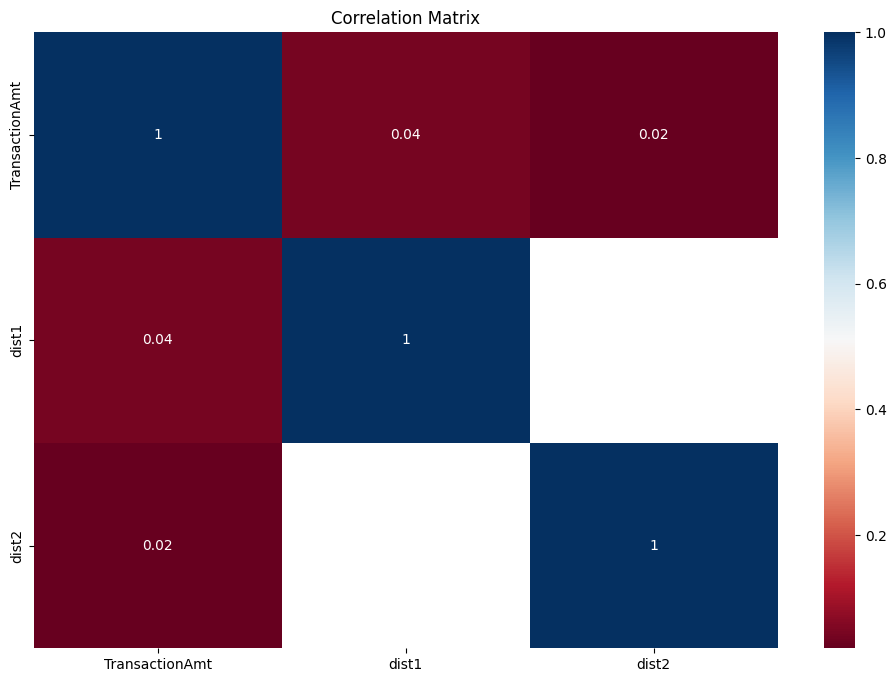

In [34]:
#Raw Feature Correlation Analysis

numeric_columns = [ "TransactionAmt", "dist1", "dist2"]

correlation_analysis( transactions_sample_clean, numeric_columns );

In [35]:
categorical_cols_transactions = {
    "ProductCD": "Product Code",

    "card4": "Card Network",
    "card6": "Card Type",

    "addr1": "Billing Region",
    "addr2": "Billing Country",

    "P_emaildomain": "Purchaser Email Domain",
    "R_emaildomain": "Recipient Email Domain",

    "M1": "M1",
    "M2": "M2",
    "M3": "M3",
    "M4": "M4",
    "M5": "M5",
    "M6": "M6",
    "M7": "M7",
    "M8": "M8",
    "M9": "M9"
}

distribution_analysis(transactions_sample_clean, categorical_cols_transactions);


Product Code Distribution


,Count,Percentage
ProductCD,,
W,56878,56.88
H,15521,15.52
R,13724,13.72
C,11351,11.35
S,2526,2.53



Card Network Distribution


,Count,Percentage
card4,,
visa,65602,65.60
mastercard,29599,29.60
american express,3330,3.33
discover,1462,1.46
NaN,7,0.01



Card Type Distribution


...

,Count,Percentage
M7,,
NaN,83961,83.96
F,13777,13.78
T,2262,2.26



M8 Distribution


,Count,Percentage
M8,,
NaN,83961,83.96
F,9956,9.96
T,6083,6.08



M9 Distribution


,Count,Percentage
M9,,
NaN,83961,83.96
T,13744,13.74
F,2295,2.30


In [36]:
categorical_cols_identity = {
    "DeviceType": "Device Type",
    "DeviceInfo": "Device Info",
    "id_30": "Operating System",
    "id_31": "Browser",
    "id_33": "Screen Resolution",
}

distribution_analysis(identity_sample_clean, categorical_cols_identity);


Device Type Distribution


,Count,Percentage
DeviceType,,
desktop,27697,66.83
mobile,12586,30.37
NaN,1163,2.81



Device Info Distribution


,Count,Percentage
DeviceInfo,,
Windows,15517,37.44
iOS Device,6635,16.01
NaN,4981,12.02
MacOS,4914,11.86
Trident/7.0,3144,7.59
rv:11.0,823,1.99
rv:57.0,526,1.27
SM-G950U Build/NRD90M,121,0.29
SM-G930V Build/NRD90M,121,0.29



Operating System Distribution


,Count,Percentage
id_30,,
NaN,11610,28.01
Windows 10,8281,19.98
Windows 7,6124,14.78
iOS 11.1.2,2611,6.30
Mac OS X 10_12_6,1138,2.75
Android 7.0,1124,2.71
Mac OS X 10_11_6,936,2.26
iOS 11.2.1,862,2.08
Windows 8.1,854,2.06



Browser Distribution


,Count,Percentage
id_31,,
chrome 63.0,8104,19.55
chrome 62.0,6372,15.37
mobile safari 11.0,5191,12.52
ie 11.0 for desktop,3867,9.33
safari generic,3292,7.94
firefox 57.0,2003,4.83
chrome 62.0 for android,1506,3.63
mobile safari 10.0,1382,3.33
chrome 63.0 for android,1294,3.12



Screen Resolution Distribution


,Count,Percentage
id_33,,
NaN,13881,33.49
1920x1080,6947,16.76
1366x768,3179,7.67
1334x750,2073,5.00
1440x900,1797,4.34
1600x900,1598,3.86
2048x1536,1545,3.73
2208x1242,1474,3.56
1280x800,837,2.02



End of Python EDA phase.

transactions_clean.csv / identity_clean.csv (the ~100K
time-ordered sample produced above) are uploaded to BigQuery
and processed through the SQL pipeline in sql/01_ingestion/
through sql/05_validation/.

Downstream engineered features, risk scoring, and validation
are handled entirely in SQL, not in this notebook — see the
sql/ folder and README for the full pipeline.
